In [1]:
import os 
import sys
sys.path.append(os.path.abspath("../"))

# Import Libraries

In [4]:
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import load_model

# Load all features and labels

In [5]:
X = np.load("../data/processed/features.npy")
y = np.load("../data/processed/labels.npy")

# Encode labels

In [6]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Split data

In [ ]:
from src.config import TEST_SIZE, RANDOM_SEED
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_encoded
)

# Scale features

In [ ]:
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)

# Load trained model

In [ ]:
model = load_model("../models/emotion_model.h5")
pred = model.predict(X_test_scaled)
pred_classes = pred.argmax(axis=1)

# Convert labels to emotion strings

In [ ]:
encoder = joblib.load("../models/label_encoder.pkl")
y_test_labels = encoder.inverse_transform(y_test)
pred_labels = encoder.inverse_transform(pred_classes)

# Accuracy

Model Accuracy: 0.9305555555555556
              precision    recall  f1-score   support

       angry       0.97      0.95      0.96        38
        calm       0.95      0.97      0.96        38
     disgust       0.89      0.87      0.88        38
     fearful       0.93      1.00      0.96        39
       happy       0.86      0.92      0.89        39
     neutral       0.90      0.95      0.92        19
         sad       1.00      0.89      0.94        38
   surprised       0.95      0.90      0.92        39

    accuracy                           0.93       288
   macro avg       0.93      0.93      0.93       288
weighted avg       0.93      0.93      0.93       288



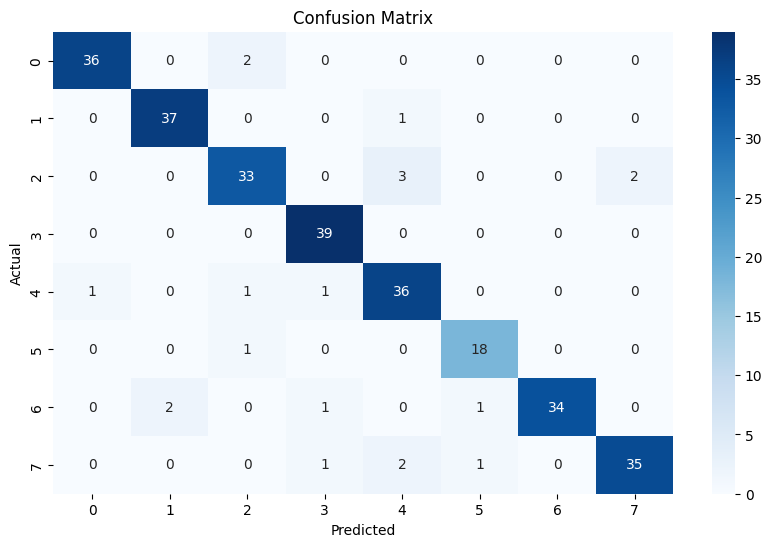

In [7]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

accuracy = accuracy_score(y_test_labels, pred_labels)
print("Model Accuracy:", accuracy)
print(classification_report(y_test_labels, pred_labels))

cm = confusion_matrix(y_test_labels, pred_labels)
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()